⏳ Running simulations (this may take ~30s)…
  [1/5] Milgram simulation…
  [2/5] Watts–Strogatz sweep…
  [3/5] Barabási–Albert graph…
  [4/5] Decentralized search experiment…
  [5/5] Building network visualisations…

✅ Figure saved → small_world_networks.png


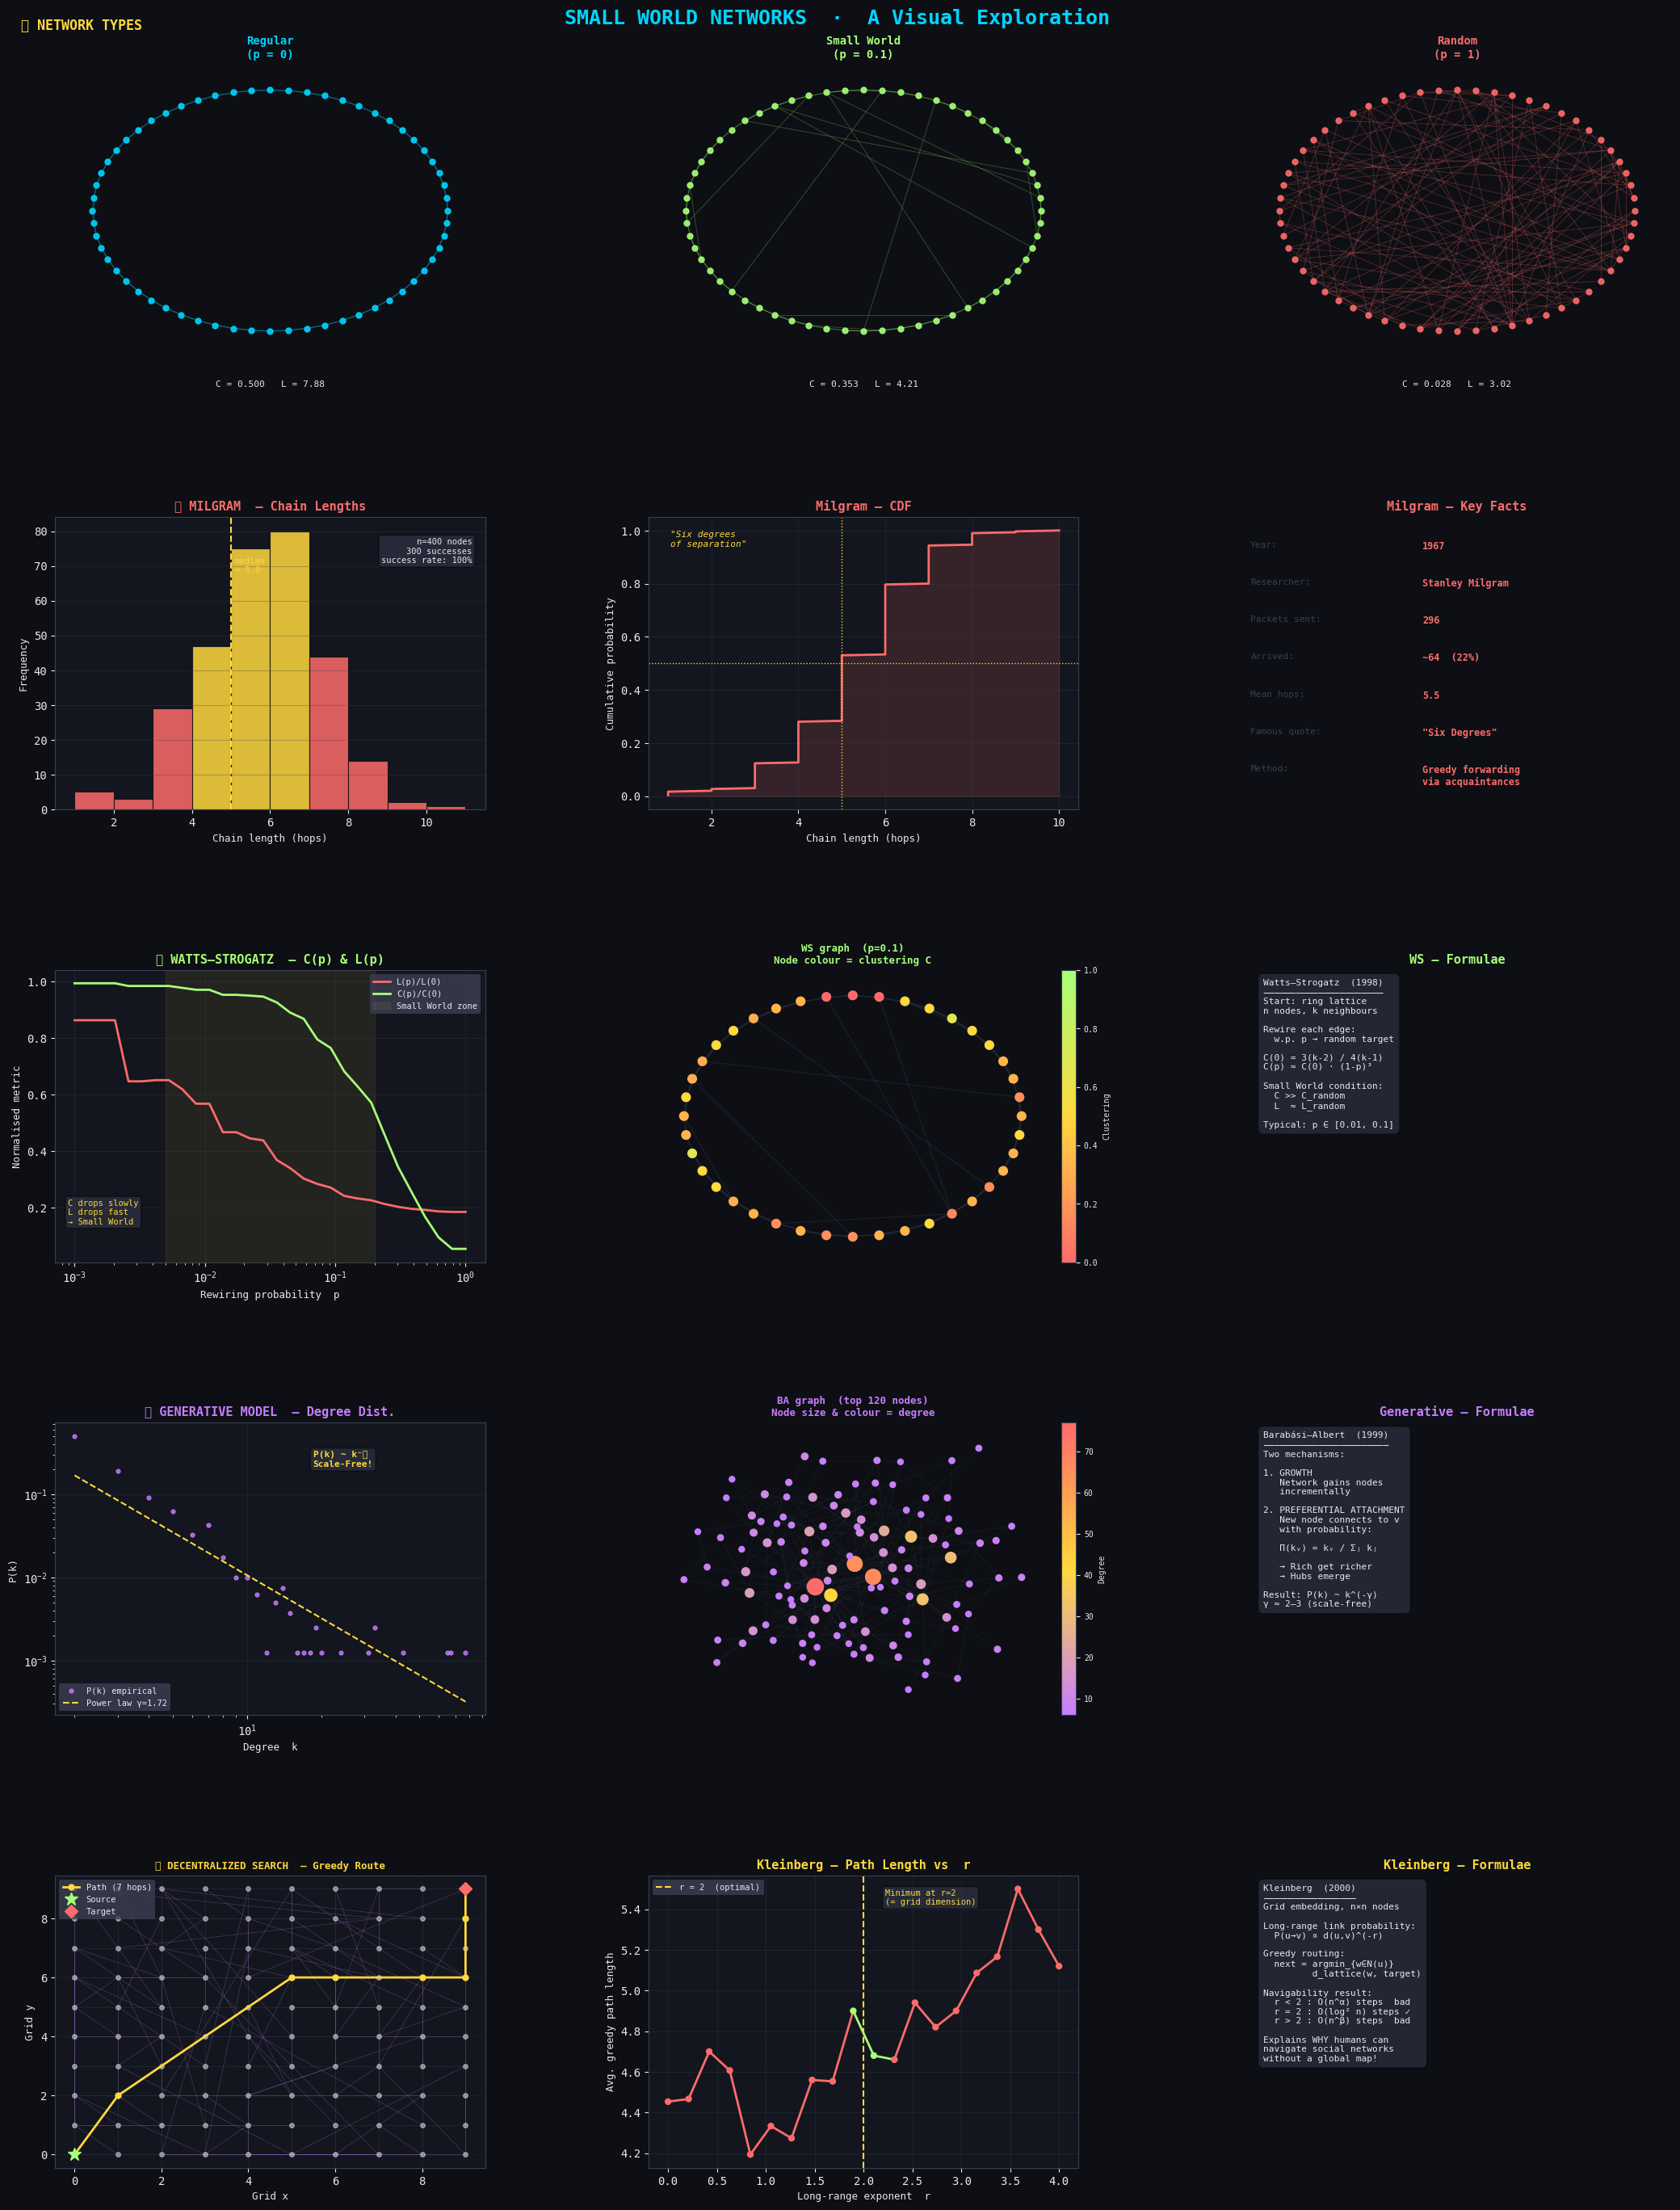


Done! All 5 topics illustrated:
  ① Network types (Regular / Small-World / Random)
  ② Milgram's experiment simulation
  ③ Watts–Strogatz C(p) & L(p) sweep
  ④ Barabási–Albert generative model (scale-free)
  ⑤ Kleinberg decentralized search


In [2]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║          SMALL WORLD NETWORKS — A COMPLETE VISUAL ILLUSTRATION               ║
║  Topics: Small World Effect · Milgram's Experiment · Watts–Strogatz Model   ║
║          Generative Model · Decentralized Search                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

THEORY PRIMER
─────────────
The "Small World" phenomenon: despite being part of a large network, most
nodes can be reached from any other node in surprisingly few steps.

Key insight: Real-world networks (social, biological, technological) are
neither completely regular (lattice) nor completely random (Erdős–Rényi),
but occupy a sweet spot in between — the "Small World" regime.

Metrics that define a Small World Network:
  • High Clustering Coefficient C: neighbours of a node tend to know each other
      C = (number of closed triangles) / (number of connected triples)
  • Short Average Path Length L: few hops to reach any node
      L = (1 / n(n-1)) * Σᵢ Σⱼ d(i,j)   [mean shortest path over all pairs]

A network is "small world" if:
  C_network >> C_random   AND   L_network ≈ L_random
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from collections import defaultdict, deque
import random
import warnings
warnings.filterwarnings("ignore")

# ── Aesthetic palette ────────────────────────────────────────────────────────
BG       = "#0D0F14"
PANEL    = "#13161E"
ACCENT1  = "#00D4FF"   # cyan
ACCENT2  = "#FF6B6B"   # coral
ACCENT3  = "#A8FF78"   # lime
ACCENT4  = "#FFD93D"   # gold
ACCENT5  = "#C77DFF"   # violet
GREY     = "#3A3F52"
TEXTCOL  = "#E8EAF0"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GREY,
    "axes.labelcolor":   TEXTCOL,
    "xtick.color":       TEXTCOL,
    "ytick.color":       TEXTCOL,
    "text.color":        TEXTCOL,
    "grid.color":        GREY,
    "grid.alpha":        0.4,
    "font.family":       "monospace",
    "axes.titlesize":    11,
    "axes.labelsize":    9,
})

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — MILGRAM'S SMALL WORLD EXPERIMENT (1967)
# ═══════════════════════════════════════════════════════════════════════════════
"""
Stanley Milgram (1967) mailed packages to 296 random people in Nebraska/Kansas
asking them to forward to a target in Boston via personal acquaintances only.
  → ~64 letters arrived;  mean chain length ≈ 5.5 hops  → "Six Degrees of Separation"

This simulation reproduces the experiment on a synthetic social graph.
"""

def simulate_milgram(n_nodes=500, n_trials=200, k=6, p=0.1, seed=42):
    """
    Simulate letter-forwarding chains on a Watts–Strogatz graph.

    Parameters
    ----------
    n_nodes : int   — population size
    n_trials : int  — number of source→target pairs tried
    k        : int  — each node initially connected to k nearest neighbours
    p        : float — rewiring probability (controls 'small-worldness')
    seed     : int  — reproducibility

    Returns
    -------
    chain_lengths : list[int]  — successful chain lengths
    success_rate  : float      — fraction of trials that reached target
    """
    rng = random.Random(seed)
    G = nx.watts_strogatz_graph(n_nodes, k, p, seed=seed)

    chain_lengths = []
    successes = 0

    for _ in range(n_trials):
        src = rng.randint(0, n_nodes - 1)
        tgt = rng.randint(0, n_nodes - 1)
        while tgt == src:
            tgt = rng.randint(0, n_nodes - 1)

        # BFS shortest path  (Milgram's participants chose "friends" optimally)
        try:
            path = nx.shortest_path(G, src, tgt)
            chain_lengths.append(len(path) - 1)   # edges, not nodes
            successes += 1
        except nx.NetworkXNoPath:
            pass   # disconnected component → letter lost

    return chain_lengths, successes / n_trials


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — WATTS–STROGATZ (WS) MODEL
# ═══════════════════════════════════════════════════════════════════════════════
"""
Duncan Watts & Steven Strogatz (1998) proposed a generative model that
interpolates between a regular ring lattice and a random graph via a
single rewiring parameter p ∈ [0, 1].

Algorithm:
  1. Start with a ring of n nodes, each connected to its k nearest neighbours.
  2. For each edge (u, v), with probability p:
       → Remove (u, v) and add (u, w) where w is chosen uniformly at random.

Effect of p on network properties:
  p ≈ 0  → Regular lattice:  high C, high L
  p ≈ 1  → Random graph   :  low  C, low  L
  p ≈ 0.01–0.1 → SMALL WORLD: high C, low L  ← the sweet spot

Formulae:
  Clustering coefficient of WS model:
      C(p) ≈ C(0) · (1 - p)³   where C(0) = 3(k-2)/[4(k-1)]

  Average path length (approximation for small p):
      L(p) ≈ L(0)  for p → 0,  L(p) ≈ ln(n)/ln(k)  for p → 1
"""

def watts_strogatz_sweep(n=300, k=6, p_values=None, seed=42):
    """
    Compute clustering coefficient C and average path length L
    for a range of rewiring probabilities p.

    Returns normalised C(p)/C(0) and L(p)/L(0) for comparison.
    """
    if p_values is None:
        p_values = np.logspace(-3, 0, 30)

    C_vals, L_vals = [], []

    G0 = nx.watts_strogatz_graph(n, k, 0.0, seed=seed)
    C0 = nx.average_clustering(G0)
    # Use a small sample for path length (expensive on large graphs)
    L0 = nx.average_shortest_path_length(G0)

    for p in p_values:
        G = nx.watts_strogatz_graph(n, k, p, seed=seed)
        C_vals.append(nx.average_clustering(G))
        if nx.is_connected(G):
            L_vals.append(nx.average_shortest_path_length(G))
        else:
            # Use largest connected component
            lcc = G.subgraph(max(nx.connected_components(G), key=len))
            L_vals.append(nx.average_shortest_path_length(lcc))

    return (p_values,
            np.array(C_vals) / C0,
            np.array(L_vals) / L0)


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — THE GENERATIVE MODEL (Barabási–Albert preferential attachment)
# ═══════════════════════════════════════════════════════════════════════════════
"""
Albert-László Barabási & Réka Albert (1999) observed that many real networks
(WWW, citations, social networks) have degree distributions following a
POWER LAW:  P(k) ~ k^(-γ)   where γ ≈ 2–3

This is called a "Scale-Free" network. It arises from two mechanisms:
  1. Growth        — the network grows over time (nodes are added)
  2. Preferential Attachment — new nodes connect to existing nodes with
                               probability proportional to their degree

     Π(kᵢ) = kᵢ / Σⱼ kⱼ   ← rich-get-richer / "Matthew effect"

The BA model is a generative model because it describes HOW the network grows,
not just what it looks like. It produces hubs (high-degree nodes) naturally.

Power law signature: log P(k) vs log k is a straight line with slope -γ
"""

def barabasi_albert_degree_distribution(n=1000, m=2, seed=42):
    """
    Build a BA preferential attachment graph and extract degree distribution.

    Parameters
    ----------
    n : int  — final number of nodes
    m : int  — edges added per new node
    seed     — reproducibility

    Returns
    -------
    degrees : np.array of node degrees
    """
    G = nx.barabasi_albert_graph(n, m, seed=seed)
    degrees = np.array([d for _, d in G.degree()])
    return G, degrees


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — DECENTRALIZED SEARCH (Kleinberg's Navigability, 2000)
# ═══════════════════════════════════════════════════════════════════════════════
"""
Jon Kleinberg (2000) asked: WHY can people find short paths without a global
map? i.e., how does greedy forwarding work?

His model embeds nodes on a 2D grid. Each node has:
  • Local edges to k nearest grid neighbours
  • Long-range (weak-tie) edges drawn with probability:
        P(u → v) ∝ d(u,v)^(-r)
  where d(u,v) is the lattice distance and r is a tunable exponent.

Key result:
  r = 2  (in 2D) → greedy search takes O(log² n) steps  ← OPTIMAL
  r < 2  → long links are too random (skip past target)
  r > 2  → long links are too local  (can't escape neighbourhood)

"Decentralized Search" = greedy forwarding: at each step, forward to
the neighbour CLOSEST to the target in lattice distance.

Delivery time T(r) as a function of r shows a minimum at r = grid_dim.
"""

def kleinberg_grid(n=15, k=1, r=2.0, seed=42):
    """
    Build a Kleinberg small-world grid.

    Parameters
    ----------
    n : int    — grid side length  (n×n nodes)
    k : int    — number of long-range contacts per node
    r : float  — distance exponent controlling long-range link distribution

    Returns
    -------
    G        : NetworkX graph
    pos      : dict node → (x,y) lattice position
    long_edges : set of long-range edges (for visualisation)
    """
    rng = random.Random(seed)
    G = nx.grid_2d_graph(n, n)   # local lattice edges
    pos = {node: node for node in G.nodes()}
    long_edges = set()

    nodes = list(G.nodes())
    for u in nodes:
        # Compute unnormalised weights: w(v) ∝ d(u,v)^(-r)
        weights = []
        candidates = []
        for v in nodes:
            if v == u or G.has_edge(u, v):
                continue
            dist = abs(u[0]-v[0]) + abs(u[1]-v[1])   # Manhattan distance
            if dist > 0:
                weights.append(dist ** (-r))
                candidates.append(v)

        if not candidates:
            continue

        total = sum(weights)
        probs = [w / total for w in weights]

        # Draw k long-range contacts
        chosen = rng.choices(candidates, weights=probs, k=k)
        for v in chosen:
            G.add_edge(u, v)
            long_edges.add((u, v))

    return G, pos, long_edges


def greedy_search(G, pos, source, target):
    """
    Decentralized greedy routing: always move to the neighbour
    geometrically closest to the target, using only LOCAL information.

    Formula:  next_hop = argmin_{v ∈ N(current)} d_lattice(v, target)

    Returns the path taken (list of nodes) or None if stuck.
    """
    path = [source]
    current = source
    visited = {source}
    max_steps = len(G.nodes)   # safety limit

    while current != target and len(path) < max_steps:
        neighbours = list(G.neighbors(current))
        if not neighbours:
            return None   # dead end

        def lattice_dist(node):
            return abs(node[0] - target[0]) + abs(node[1] - target[1])

        next_hop = min(neighbours, key=lattice_dist)

        if next_hop in visited:
            return None   # stuck in cycle

        path.append(next_hop)
        visited.add(next_hop)
        current = next_hop

    return path if current == target else None


def decentralized_search_experiment(n=15, r_values=None, n_trials=200, seed=42):
    """
    Measure average greedy-search path length vs long-range exponent r.

    Theory predicts a minimum around r = 2 (= grid dimension).
    """
    if r_values is None:
        r_values = np.linspace(0, 4, 20)

    avg_lengths = []
    success_rates = []
    rng = random.Random(seed)

    nodes_list = [(i, j) for i in range(n) for j in range(n)]

    for r in r_values:
        G, pos, _ = kleinberg_grid(n=n, r=r, seed=seed)
        lengths = []
        successes = 0
        for _ in range(n_trials):
            src = rng.choice(nodes_list)
            tgt = rng.choice(nodes_list)
            while tgt == src:
                tgt = rng.choice(nodes_list)
            path = greedy_search(G, pos, src, tgt)
            if path is not None:
                lengths.append(len(path) - 1)
                successes += 1

        avg_lengths.append(np.mean(lengths) if lengths else n*n)
        success_rates.append(successes / n_trials)

    return r_values, np.array(avg_lengths), np.array(success_rates)


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — NETWORK COMPARISON: Regular vs Small-World vs Random
# ═══════════════════════════════════════════════════════════════════════════════

def build_three_networks(n=50, k=4, seed=42):
    """
    Build the three canonical network types for visual comparison:
      • Regular ring lattice   (p=0)
      • Small-world WS         (p=0.1)
      • Random Erdős–Rényi     (p=1 rewired ≈ random)

    Returns dict of {name: (G, pos, color)}
    """
    G_reg = nx.watts_strogatz_graph(n, k, 0.00, seed=seed)
    G_sw  = nx.watts_strogatz_graph(n, k, 0.10, seed=seed)
    G_rnd = nx.watts_strogatz_graph(n, k, 1.00, seed=seed)

    pos_reg = nx.circular_layout(G_reg)
    pos_sw  = nx.circular_layout(G_sw)
    pos_rnd = nx.circular_layout(G_rnd)

    return {
        "Regular\n(p = 0)":      (G_reg, pos_reg, ACCENT1),
        "Small World\n(p = 0.1)": (G_sw,  pos_sw,  ACCENT3),
        "Random\n(p = 1)":       (G_rnd, pos_rnd, ACCENT2),
    }


# ═══════════════════════════════════════════════════════════════════════════════
# MASTER VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    print("⏳ Running simulations (this may take ~30s)…")

    # --- Pre-compute everything ---
    print("  [1/5] Milgram simulation…")
    chain_lengths, success_rate = simulate_milgram(n_nodes=400, n_trials=300)

    print("  [2/5] Watts–Strogatz sweep…")
    p_vals, C_norm, L_norm = watts_strogatz_sweep(n=200, k=6)

    print("  [3/5] Barabási–Albert graph…")
    BA_G, degrees = barabasi_albert_degree_distribution(n=800, m=2)

    print("  [4/5] Decentralized search experiment…")
    r_vals, avg_len, suc_rate = decentralized_search_experiment(n=12, n_trials=150)

    print("  [5/5] Building network visualisations…")
    networks = build_three_networks(n=60, k=4)
    # Kleinberg grid for display (small, one example)
    K_G, K_pos, K_long = kleinberg_grid(n=10, r=2.0, seed=7)
    src_node, tgt_node = (0,0), (9,9)
    search_path = greedy_search(K_G, K_pos, src_node, tgt_node)

    # ── Layout ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(22, 28), facecolor=BG)
    fig.suptitle(
        "SMALL WORLD NETWORKS  ·  A Visual Exploration",
        fontsize=18, fontweight="bold", color=ACCENT1,
        y=0.985, fontfamily="monospace"
    )

    gs = gridspec.GridSpec(
        5, 3, figure=fig,
        hspace=0.55, wspace=0.38,
        top=0.96, bottom=0.03, left=0.06, right=0.97
    )

    # ──────────────────────────────────────────────────────────────────────────
    # ROW 0: Three network types
    # ──────────────────────────────────────────────────────────────────────────
    row0_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

    for ax, (title, (G, pos, col)) in zip(row0_axes, networks.items()):
        C = nx.average_clustering(G)
        if nx.is_connected(G):
            L = nx.average_shortest_path_length(G)
        else:
            lcc = G.subgraph(max(nx.connected_components(G), key=len))
            L = nx.average_shortest_path_length(lcc)

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25,
                               edge_color=col, width=0.7)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=25,
                               node_color=col, alpha=0.9)
        ax.set_title(title, color=col, fontweight="bold", fontsize=10)
        ax.set_axis_off()
        ax.text(0.5, -0.08,
                f"C = {C:.3f}   L = {L:.2f}",
                ha='center', va='top', transform=ax.transAxes,
                fontsize=8, color=TEXTCOL)

    row0_axes[0].text(-0.08, 1.12, "① NETWORK TYPES",
                      transform=row0_axes[0].transAxes,
                      fontsize=12, color=ACCENT4, fontweight="bold")

    # ──────────────────────────────────────────────────────────────────────────
    # ROW 1: Milgram simulation results (2 panels) + chain length histogram
    # ──────────────────────────────────────────────────────────────────────────
    row1_axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

    # 1A — Chain length histogram
    ax = row1_axes[0]
    ax.set_facecolor(PANEL)
    bins = range(min(chain_lengths), max(chain_lengths)+2)
    counts, edges, patches = ax.hist(chain_lengths, bins=bins,
                                     color=ACCENT2, alpha=0.85,
                                     edgecolor=BG, linewidth=0.8)
    # Colour the bar at median differently
    median_len = np.median(chain_lengths)
    for patch, left in zip(patches, edges[:-1]):
        if abs(left - round(median_len)) <= 1:
            patch.set_facecolor(ACCENT4)
    ax.axvline(median_len, color=ACCENT4, linewidth=1.5, linestyle='--')
    ax.text(median_len + 0.1, max(counts)*0.85,
            f"median\n= {median_len:.1f}",
            color=ACCENT4, fontsize=7.5)
    ax.set_xlabel("Chain length (hops)")
    ax.set_ylabel("Frequency")
    ax.set_title("② MILGRAM  — Chain Lengths", color=ACCENT2, fontweight="bold")
    ax.text(0.97, 0.93,
            f"n=400 nodes\n{len(chain_lengths)} successes\n"
            f"success rate: {success_rate:.0%}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=7.5, color=TEXTCOL,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=GREY, alpha=0.5))
    ax.grid(axis='y', alpha=0.3)

    # 1B — Cumulative distribution
    ax = row1_axes[1]
    ax.set_facecolor(PANEL)
    sorted_lens = np.sort(chain_lengths)
    cdf = np.arange(1, len(sorted_lens)+1) / len(sorted_lens)
    ax.plot(sorted_lens, cdf, color=ACCENT2, linewidth=2)
    ax.fill_between(sorted_lens, cdf, alpha=0.15, color=ACCENT2)
    ax.axhline(0.5, color=ACCENT4, linewidth=1, linestyle=':')
    ax.axvline(median_len, color=ACCENT4, linewidth=1, linestyle=':')
    ax.set_xlabel("Chain length (hops)")
    ax.set_ylabel("Cumulative probability")
    ax.set_title("Milgram — CDF", color=ACCENT2, fontweight="bold")
    ax.text(0.05, 0.9,
            '"Six degrees\nof separation"',
            transform=ax.transAxes, color=ACCENT4,
            fontsize=8, style='italic')
    ax.grid(alpha=0.3)

    # 1C — Milgram by the numbers (infographic-style)
    ax = row1_axes[2]
    ax.set_facecolor(PANEL)
    ax.set_axis_off()
    facts = [
        ("Year",          "1967"),
        ("Researcher",    "Stanley Milgram"),
        ("Packets sent",  "296"),
        ("Arrived",       "~64  (22%)"),
        ("Mean hops",     "5.5"),
        ("Famous quote",  '"Six Degrees"'),
        ("Method",        "Greedy forwarding\nvia acquaintances"),
    ]
    for i, (k_lbl, v_lbl) in enumerate(facts):
        y = 0.92 - i * 0.128
        ax.text(0.02, y, k_lbl + ":", transform=ax.transAxes,
                fontsize=8, color=GREY, va='top')
        ax.text(0.42, y, v_lbl, transform=ax.transAxes,
                fontsize=8.5, color=ACCENT2, fontweight="bold", va='top')
    ax.set_title("Milgram — Key Facts", color=ACCENT2, fontweight="bold")

    # ──────────────────────────────────────────────────────────────────────────
    # ROW 2: Watts–Strogatz sweep
    # ──────────────────────────────────────────────────────────────────────────
    row2_axes = [fig.add_subplot(gs[2, 0]),
                 fig.add_subplot(gs[2, 1]),
                 fig.add_subplot(gs[2, 2])]

    # 2A — C(p) and L(p) normalised
    ax = row2_axes[0]
    ax.set_facecolor(PANEL)
    ax.semilogx(p_vals, L_norm, color=ACCENT2, linewidth=2, label="L(p)/L(0)")
    ax.semilogx(p_vals, C_norm, color=ACCENT3, linewidth=2, label="C(p)/C(0)")
    ax.axvspan(0.005, 0.2, alpha=0.07, color=ACCENT4,
               label="Small World zone")
    ax.set_xlabel("Rewiring probability  p")
    ax.set_ylabel("Normalised metric")
    ax.set_title("③ WATTS–STROGATZ  — C(p) & L(p)", color=ACCENT3, fontweight="bold")
    ax.legend(fontsize=7.5, facecolor=GREY, edgecolor='none')
    ax.grid(alpha=0.3)
    ax.text(0.03, 0.13,
            "C drops slowly\nL drops fast\n→ Small World",
            transform=ax.transAxes, fontsize=7.5, color=ACCENT4,
            bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.5))

    # 2B — Single WS graph visualisation
    ax = row2_axes[1]
    G_demo = nx.watts_strogatz_graph(40, 4, 0.1, seed=42)
    pos_demo = nx.circular_layout(G_demo)
    # Colour nodes by clustering coefficient
    clust = nx.clustering(G_demo)
    node_colors = [clust[n] for n in G_demo.nodes()]
    cmap_node = LinearSegmentedColormap.from_list(
        "cc", [ACCENT2, ACCENT4, ACCENT3])
    nx.draw_networkx_edges(G_demo, pos_demo, ax=ax,
                           alpha=0.3, edge_color=GREY)
    sc = nx.draw_networkx_nodes(G_demo, pos_demo, ax=ax,
                                node_size=60,
                                node_color=node_colors,
                                cmap=cmap_node, vmin=0, vmax=1)
    ax.set_axis_off()
    ax.set_title("WS graph  (p=0.1)\nNode colour = clustering C",
                 color=ACCENT3, fontweight="bold", fontsize=9)
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_node,
                        norm=plt.Normalize(0, 1)),
                        ax=ax, fraction=0.04, pad=0.01)
    cbar.ax.tick_params(colors=TEXTCOL, labelsize=7)
    cbar.set_label("Clustering", color=TEXTCOL, fontsize=7)

    # 2C — WS formula & parameter table
    ax = row2_axes[2]
    ax.set_facecolor(PANEL)
    ax.set_axis_off()
    formulas = (
        "Watts–Strogatz  (1998)\n"
        "──────────────────────\n"
        "Start: ring lattice\n"
        "n nodes, k neighbours\n\n"
        "Rewire each edge:\n"
        "  w.p. p → random target\n\n"
        "C(0) = 3(k-2) / 4(k-1)\n"
        "C(p) ≈ C(0) · (1-p)³\n\n"
        "Small World condition:\n"
        "  C >> C_random\n"
        "  L  ≈ L_random\n\n"
        "Typical: p ∈ [0.01, 0.1]"
    )
    ax.text(0.05, 0.97, formulas,
            transform=ax.transAxes,
            fontsize=8, color=TEXTCOL, va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.5, pad=0.6))
    ax.set_title("WS — Formulae", color=ACCENT3, fontweight="bold")

    # ──────────────────────────────────────────────────────────────────────────
    # ROW 3: Barabási–Albert generative model
    # ──────────────────────────────────────────────────────────────────────────
    row3_axes = [fig.add_subplot(gs[3, 0]),
                 fig.add_subplot(gs[3, 1]),
                 fig.add_subplot(gs[3, 2])]

    # 3A — Degree distribution log-log
    ax = row3_axes[0]
    ax.set_facecolor(PANEL)
    deg_vals, counts = np.unique(degrees, return_counts=True)
    prob = counts / counts.sum()
    ax.loglog(deg_vals, prob, 'o', markersize=3.5,
              color=ACCENT5, alpha=0.8, label="P(k) empirical")
    # Fit power law: log P = -γ log k + const
    mask = (deg_vals >= 2) & (prob > 0)
    if mask.sum() > 2:
        coeffs = np.polyfit(np.log(deg_vals[mask]), np.log(prob[mask]), 1)
        gamma = -coeffs[0]
        k_fit = np.linspace(deg_vals[mask].min(), deg_vals[mask].max(), 100)
        ax.loglog(k_fit, np.exp(coeffs[1]) * k_fit**coeffs[0],
                  '--', color=ACCENT4, linewidth=1.5,
                  label=f"Power law γ={gamma:.2f}")
    ax.set_xlabel("Degree  k")
    ax.set_ylabel("P(k)")
    ax.set_title("④ GENERATIVE MODEL  — Degree Dist.", color=ACCENT5, fontweight="bold")
    ax.legend(fontsize=7.5, facecolor=GREY, edgecolor='none')
    ax.grid(alpha=0.3)
    ax.text(0.6, 0.85,
            "P(k) ~ k⁻ᵞ\nScale-Free!",
            transform=ax.transAxes, fontsize=8, color=ACCENT4,
            fontweight="bold",
            bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.5))

    # 3B — BA graph visualised (subsample for speed)
    ax = row3_axes[1]
    sub_nodes = sorted(dict(BA_G.degree()).items(),
                       key=lambda x: x[1], reverse=True)[:120]
    sub_ids = [n for n, _ in sub_nodes]
    G_sub = BA_G.subgraph(sub_ids)
    pos_ba = nx.spring_layout(G_sub, seed=42, k=0.4)
    deg_sub = np.array([BA_G.degree(n) for n in G_sub.nodes()])
    node_sz  = (deg_sub / deg_sub.max() * 200 + 10).tolist()
    node_col = deg_sub.tolist()
    cmap_ba = LinearSegmentedColormap.from_list("ba", [ACCENT5, ACCENT4, ACCENT2])
    nx.draw_networkx_edges(G_sub, pos_ba, ax=ax, alpha=0.15, edge_color=GREY)
    sc2 = nx.draw_networkx_nodes(G_sub, pos_ba, ax=ax,
                                 node_size=node_sz,
                                 node_color=node_col, cmap=cmap_ba)
    ax.set_axis_off()
    ax.set_title("BA graph  (top 120 nodes)\nNode size & colour = degree",
                 color=ACCENT5, fontweight="bold", fontsize=9)
    cbar2 = fig.colorbar(plt.cm.ScalarMappable(
        cmap=cmap_ba,
        norm=plt.Normalize(deg_sub.min(), deg_sub.max())),
        ax=ax, fraction=0.04, pad=0.01)
    cbar2.ax.tick_params(colors=TEXTCOL, labelsize=7)
    cbar2.set_label("Degree", color=TEXTCOL, fontsize=7)

    # 3C — Preferential attachment illustration
    ax = row3_axes[2]
    ax.set_facecolor(PANEL)
    ax.set_axis_off()
    pa_text = (
        "Barabási–Albert  (1999)\n"
        "───────────────────────\n"
        "Two mechanisms:\n\n"
        "1. GROWTH\n"
        "   Network gains nodes\n"
        "   incrementally\n\n"
        "2. PREFERENTIAL ATTACHMENT\n"
        "   New node connects to v\n"
        "   with probability:\n\n"
        "   Π(kᵥ) = kᵥ / Σⱼ kⱼ\n\n"
        "   → Rich get richer\n"
        "   → Hubs emerge\n\n"
        "Result: P(k) ~ k^(-γ)\n"
        "γ ≈ 2–3 (scale-free)"
    )
    ax.text(0.05, 0.97, pa_text,
            transform=ax.transAxes,
            fontsize=8, color=TEXTCOL, va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.5, pad=0.6))
    ax.set_title("Generative — Formulae", color=ACCENT5, fontweight="bold")

    # ──────────────────────────────────────────────────────────────────────────
    # ROW 4: Decentralized Search (Kleinberg)
    # ──────────────────────────────────────────────────────────────────────────
    row4_axes = [fig.add_subplot(gs[4, 0]),
                 fig.add_subplot(gs[4, 1]),
                 fig.add_subplot(gs[4, 2])]

    # 4A — Greedy path on Kleinberg grid
    ax = row4_axes[0]
    ax.set_facecolor(PANEL)

    # Draw local edges
    for u, v in K_G.edges():
        if (u, v) not in K_long and (v, u) not in K_long:
            ax.plot([u[0], v[0]], [u[1], v[1]],
                    color=GREY, linewidth=0.5, alpha=0.5, zorder=1)
    # Draw long edges
    for (u, v) in K_long:
        ax.plot([u[0], v[0]], [u[1], v[1]],
                color=ACCENT5, linewidth=0.5, alpha=0.3, zorder=2)

    # All nodes
    for node in K_G.nodes():
        ax.plot(node[0], node[1], 'o', markersize=4,
                color=TEXTCOL, alpha=0.5, zorder=3)

    # Greedy search path
    if search_path:
        px = [n[0] for n in search_path]
        py = [n[1] for n in search_path]
        ax.plot(px, py, '-o', color=ACCENT4, linewidth=2,
                markersize=5, zorder=5, label=f"Path ({len(search_path)-1} hops)")
        ax.plot(*src_node, '*', markersize=12, color=ACCENT3,
                zorder=6, label="Source")
        ax.plot(*tgt_node, 'D', markersize=8, color=ACCENT2,
                zorder=6, label="Target")

    ax.set_title("⑤ DECENTRALIZED SEARCH  — Greedy Route", color=ACCENT4, fontweight="bold", fontsize=9)
    ax.set_xlabel("Grid x")
    ax.set_ylabel("Grid y")
    leg = ax.legend(fontsize=7.5, facecolor=GREY, edgecolor='none',
                    loc='upper left')
    ax.grid(alpha=0.2)

    # 4B — Delivery length vs exponent r
    ax = row4_axes[1]
    ax.set_facecolor(PANEL)
    sc_color = [ACCENT3 if r < 2.2 and r > 1.8 else ACCENT2 for r in r_vals]
    for i in range(len(r_vals)-1):
        ax.plot(r_vals[i:i+2], avg_len[i:i+2],
                color=sc_color[i], linewidth=2)
    ax.axvline(2.0, color=ACCENT4, linewidth=1.5, linestyle='--',
               label="r = 2  (optimal)")
    ax.scatter(r_vals, avg_len, c=sc_color, s=25, zorder=5)
    ax.set_xlabel("Long-range exponent  r")
    ax.set_ylabel("Avg. greedy path length")
    ax.set_title("Kleinberg — Path Length vs  r", color=ACCENT4, fontweight="bold")
    ax.legend(fontsize=7.5, facecolor=GREY, edgecolor='none')
    ax.grid(alpha=0.3)
    ax.text(0.55, 0.9,
            "Minimum at r=2\n(= grid dimension)",
            transform=ax.transAxes, fontsize=7.5, color=ACCENT4,
            bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.5))

    # 4C — Kleinberg formula card
    ax = row4_axes[2]
    ax.set_facecolor(PANEL)
    ax.set_axis_off()
    klein_text = (
        "Kleinberg  (2000)\n"
        "─────────────────\n"
        "Grid embedding, n×n nodes\n\n"
        "Long-range link probability:\n"
        "  P(u→v) ∝ d(u,v)^(-r)\n\n"
        "Greedy routing:\n"
        "  next = argmin_{w∈N(u)}\n"
        "         d_lattice(w, target)\n\n"
        "Navigability result:\n"
        "  r < 2 : O(n^α) steps  bad\n"
        "  r = 2 : O(log² n) steps ✓\n"
        "  r > 2 : O(n^β) steps  bad\n\n"
        "Explains WHY humans can\n"
        "navigate social networks\n"
        "without a global map!"
    )
    ax.text(0.05, 0.97, klein_text,
            transform=ax.transAxes,
            fontsize=8, color=TEXTCOL, va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.5, pad=0.6))
    ax.set_title("Kleinberg — Formulae", color=ACCENT4, fontweight="bold")

    # ── Save ──────────────────────────────────────────────────────────────────
    out = "small_world_networks.png"
    plt.savefig(out, dpi=150, bbox_inches='tight',
                facecolor=BG, edgecolor='none')
    print(f"\n✅ Figure saved → {out}")
    plt.show()
    print("\nDone! All 5 topics illustrated:")
    print("  ① Network types (Regular / Small-World / Random)")
    print("  ② Milgram's experiment simulation")
    print("  ③ Watts–Strogatz C(p) & L(p) sweep")
    print("  ④ Barabási–Albert generative model (scale-free)")
    print("  ⑤ Kleinberg decentralized search")


if __name__ == "__main__":
    main()